# Emotion Classifier

Demo: https://emotion-classification-frontend.vercel.app/

You can find the data [here](https://www.kaggle.com/datasets/uldisvalainis/audio-emotions?resource=download-directory). For this notebook to work, you either have to set up your drive like the image below, or configure data_path to match where Emotions API Data is. Have the raw data stored in Emotions, with subfolders for each emotion **there's a typo in the Kaggle dataset, so rename the "suprised" folder to "surprised"**. Don't worry about the Resampled folder, the notebook will create it when preprocessing the data.

Your data_path will be different depending on whether you are running this notebook on Google Colab or locally.


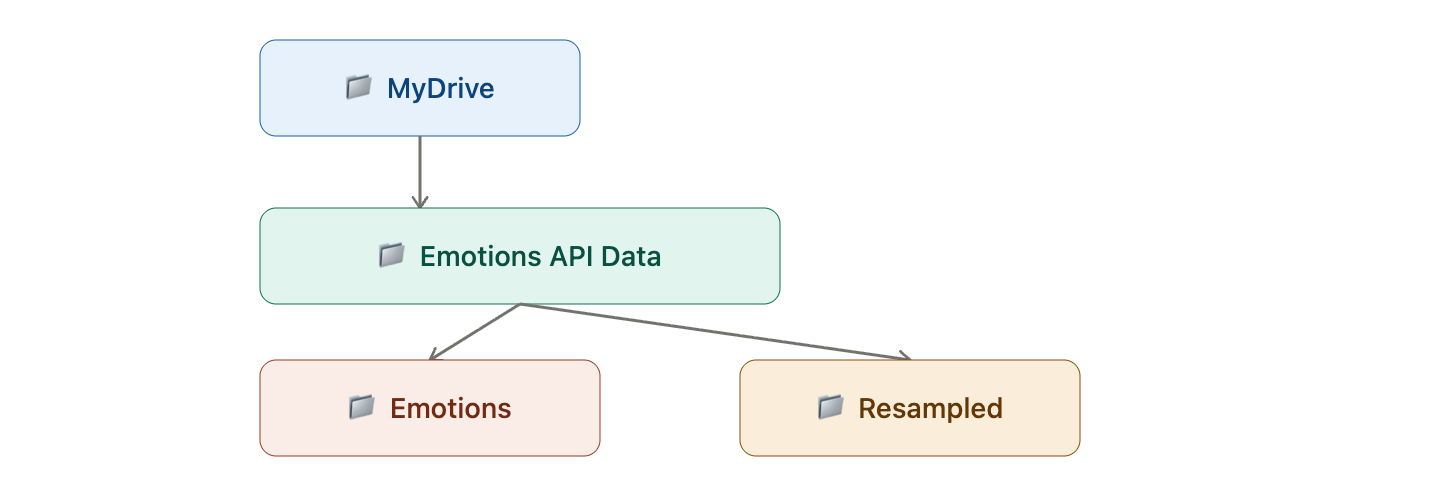

Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 # data augmentations
from torchvision.datasets import ImageFolder
from torch.optim import lr_scheduler
import timm
from transformers import HubertModel, Wav2Vec2FeatureExtractor

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

import os

from glob import glob
from pathlib import Path

import soundfile as sf
import librosa
import librosa.display

from itertools import cycle

from tqdm.notebook import tqdm # makes training progress bar

import shutil

from google.colab import drive
drive.mount("/content/drive")

data_path = '/content/drive/MyDrive/Emotions API Data'

Ensuring runs are reproducible

In [ ]:
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
g = torch.Generator().manual_seed(42)

Dictionary for labels

In [ ]:
label_dict = {
    "Angry": 0,
    "Disgusted": 1,
    "Fearful": 2,
    "Happy": 3,
    "Neutral": 4,
    "Sad": 5,
    "Surprised": 6
}

# Preprocessing - resizing the audio

This can take a while (15-20 minutes on an L4 GPU)

In [ ]:
import soundfile as sf

os.makedirs(os.path.join(data_path, 'Resampled'), exist_ok=True)

for emotion in label_dict.keys():
  os.makedirs(os.path.join(data_path, 'Resampled', emotion), exist_ok=True)

  for file_path in glob(os.path.join(data_path, 'Emotions', emotion, '*.wav')):
    y, sr = librosa.load(file_path)
    resampled_y = librosa.resample(y, orig_sr=sr, target_sr=16000)

    new_path = os.path.join(data_path, 'Resampled', emotion, os.path.basename(file_path))
    sf.write(new_path, resampled_y, 16000)

# Preparing feature extractor

Assign GPU to variable

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")
print(device)

Extracting 1x768 features from frozen HuBERT model

In [ ]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/hubert-base-ls960")
hubert = HubertModel.from_pretrained("facebook/hubert-base-ls960")
hubert.to(device)
hubert.eval()
for param in hubert.parameters():
    param.requires_grad = False

def extract_features(audio_array, sr=16000):
    inputs = feature_extractor(audio_array, sampling_rate=sr, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = hubert(**inputs)
    # mean pool over time dimension
    return outputs.last_hidden_state.mean(dim=1).cpu()  # shape: [1, 768]

Extracting features and putting them in the X_data and y_data tensors

In [ ]:
count = 0
for file_path in glob(os.path.join(data_path, 'Resampled', '*', '*.wav')):
  count += 1

X_data = torch.zeros((count, 768), dtype=torch.float)
y_data = torch.zeros((count), dtype=torch.long)

i = 0
for emotion in label_dict.keys():
  print(f"Emotion: ", emotion)
  for file_path in glob(os.path.join(data_path, 'Resampled', emotion, '*.wav')):
    # preprocessing audio into correct sample rate (16kHz)
    raw_audio, _ = librosa.load(file_path, sr=16000)
    label_number = label_dict[os.path.basename(os.path.dirname(file_path))]

    # storing data in the datasets
    X_data[i] = extract_features(raw_audio).squeeze()
    y_data[i] = label_number
    i += 1

    # DEBUG - logs and limiting dataset size for now
    if i % 100 == 0:
      print(i, f"files processed")

# DEBUG - logs
print("X dataset shape:", X_data.shape)
print("X dataset dtype:", X_data.dtype)
print("Y dataset shape:", y_data.shape)
print("Y dataset dtype:", y_data.dtype)

Dataset class

In [ ]:
class AudioEmotionsDataset(Dataset):
  def __init__(self, X_data, y_data):
    self.X_data = X_data
    self.y_data = y_data

  def __len__(self):
    return X_data.shape[0]

  def __getitem__(self, idx):
    x = self.X_data[idx]
    y = self.y_data[idx]

    return x, y

Data loader

In [ ]:
dataset = AudioEmotionsDataset(X_data, y_data)
data_loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)

Splitting data into train, val, test (0.8/0.1/0.1)

In [ ]:
from torch.utils.data import random_split

# make datasets: 0.8, 0.1, 0.1 train/val/test split
train_size = int(0.8*len(dataset))
non_train_size = len(dataset) - train_size
train_dataset, non_train_dataset = random_split(dataset, [train_size, non_train_size], generator=g)

cv_size = int(0.5*len(non_train_dataset))
test_size = len(non_train_dataset) - cv_size
val_dataset, test_dataset = random_split(non_train_dataset, [cv_size, test_size], generator=g)

# make dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

# Model Architecture

In [ ]:
class EmotionHead(nn.Module): # dense dropout layer then final dense
    def __init__(self, input_dim=768, num_classes=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# Training

In [ ]:
num_epochs = 200
train_losses = []
val_losses = []
best_val_loss = float('inf')

model = EmotionHead()
model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

for epoch in range(num_epochs):
  model.train() # sets it to training mode
  running_loss = 0.0
  for features, labels in tqdm(train_loader, desc="Training: "): # looping through batches
    features, labels = features.to(device), labels.to(device) # transfer info to GPU
    labels = labels.long() # labels are indices -> must be torch.long

    outputs = model(features) # call the forward() function
    optimizer.zero_grad() # reset the gradients after each batch
    loss = criterion(outputs, labels) # get the loss from defined function
    loss.backward() # backpropagation
    optimizer.step() # change the learning rate
    running_loss += loss.item() * features.size(0) # add loss to running total

  train_loss = running_loss / len(train_loader.dataset) # normalize training loss
  train_losses.append(train_loss)






  # validating the model
  model.eval()
  running_loss = 0.0
  with torch.no_grad():
    for features, labels in tqdm(val_loader, desc="Validating: "):
      features, labels = features.to(device), labels.to(device) # transfer info to GPU
      labels = labels.long()

      outputs = model(features)
      loss = criterion(outputs, labels)
      running_loss += loss.item() * features.size(0)

  val_loss = running_loss / len(val_loader.dataset)
  val_losses.append(val_loss)

  scheduler.step(val_loss) # change the learning rate again


  # Epoch/loss check
  print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss}, Validation loss: {val_loss}")
  if val_loss < best_val_loss:
      best_val_loss = val_loss

      torch.save(model.state_dict(), os.path.join(data_path, 'best_model.pt'))
      print(f"New best model saved at epoch {epoch}")

# Analyzing Results on test set
1. Confusion Matrix
2. Loss Graphs

In [ ]:
model = EmotionHead()
model.load_state_dict(torch.load(os.path.join(data_path, 'best_model.pt')))

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for features, labels in test_loader:
        outputs = model(features.to(device))
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=list(label_dict.keys())))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_dict.values(), yticklabels=label_dict.values())

In [ ]:
plt.plot(train_losses, label="training loss")
plt.plot(val_losses, label="validation loss")
plt.title("Loss over Epochs")
plt.legend()
plt.show()